# 🧠 Robot Anomaly Detection

Authors: Noam Amar and Or Pinto, with equal contributions.
This notebook loads robot sensor data, creates differential features, and trains a multiclass anomaly detection model.

## Handling data import, unique to environment.

In [1]:
# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# Set the path to your .parquet file
parquet_path = './data.parquet'

In [2]:
# Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Differential Feature Engineering
Creating new-features exempt from the dataset, which consist of the differences between adjacent data-points, to provide continous transformation information.

In [3]:
def create_diff_features(sub_features, df, features):
    """
    Create differential features between pairs of sensor measurements for each motor.

    This function computes the difference between each pair of features in sub_features
    for each motor and adds these differential features to the features dictionary.

    Args:
        sub_features (list): List of base feature names to create differences from
        df (DataFrame): DataFrame containing the original sensor data
        features (dict): Dictionary to store the created differential features

    Returns:
        None: Features are added to the provided features dictionary
    """
    motors = list(range(1, 7))  # Motors 1 through 6

    for i, f1 in enumerate(sub_features):
        for j in range(i + 1, len(sub_features)):
            f2 = sub_features[j]
            for motor in motors:
                motor_str = str(motor)
                feature_name = f"{f1}_diff_{f2}_{motor_str}"

                # Calculate difference between two measurements for this motor
                diff = np.subtract(
                    df[f"{f1}_{motor_str}"],
                    df[f"{f2}_{motor_str}"]
                )

                features[feature_name] = diff

## Load and Prepare Data
Extract .parquet data, and write it into a Pandas dataframe.

In [4]:
print("Loading robot sensor data...")
df = pd.read_parquet(parquet_path)

print(f"Dataset loaded with {len(df)} rows and {len(df.columns)} columns")
print("Available measurements:", ", ".join(sorted(list(set([col.split('_')[0] for col in df.columns if '_' in col])))))

features = {}

print("Generating differential features...")
create_diff_features(["motor_velocity", "joint_velocity", "target_velocity"], df, features)
create_diff_features(["motor_position", "joint_position", "target_position"], df, features)
create_diff_features(["motor_torque", "torque_sensor_a", "torque_sensor_b", "computed_torque"], df, features)

print("Adding categorical and system measurements...")
metadata_cols = ["category", "anomaly", "sample", "time"]
system_cols = ["system_current", "robot_voltage", "robot_current"]

for col in metadata_cols + system_cols:
    features[col] = df[col]

print("Adding motor current measurements...")
for i in range(1, 7):
    features[f"motor_iq_{i}"] = df[f"motor_iq_{i}"]
    features[f"motor_id_{i}"] = df[f"motor_id_{i}"]

print(f"Feature generation complete. Total features created: {len(features)}")
our_data = pd.DataFrame(features)

Loading robot sensor data...
Dataset loaded with 2321690 rows and 137 columns
Available measurements: brake, computed, io, joint, motor, power, robot, supply, system, target, torque
Generating differential features...
Adding categorical and system measurements...
Adding motor current measurements...
Feature generation complete. Total features created: 91


## Organize Samples by Category

Our dataset holds data categorized by a class, a class of 'Clean' (no anomalies whatsoever)
and classes for each tested-anomaly (e.g, additional friction, additional weight, miscommutation...)

In [5]:
def organize_samples_by_category(dataframe):
    """
    Organize time series samples into clean and anomaly categories.

    Args:
        dataframe (pd.DataFrame): DataFrame containing the features with sample and anomaly columns

    Returns:
        tuple: (samples, clean_samples, anomaly_samples) where:
               - samples is a list of all sample time series
               - clean_samples is a list of normal operation samples
               - anomaly_samples is a list of lists (by category) of anomalous samples
    """
    samples = []
    clean_samples = []
    anomaly_samples = [[] for _ in range(12)]  # 12 anomaly categories

    # Group data by sample ID
    for _, group in dataframe.groupby('sample'):
        samples.append(group)

    # Categorize samples as clean or by anomaly type
    for sample in samples:
        first_point = sample.iloc[0]
        if first_point["anomaly"]:
            anomaly_samples[first_point["category"]].append(sample)
        else:
            clean_samples.append(sample)

    return samples, clean_samples, anomaly_samples

samples, clean_samples, anomaly_samples = organize_samples_by_category(our_data)

print(f"Clean samples: {len(clean_samples)}")
for i in range(len(anomaly_samples)):
    if len(anomaly_samples[i]) > 0:
        print(f"Anomaly category {i}: {len(anomaly_samples[i])} samples")

clean_sample = clean_samples[3]
extra_friction_sample = anomaly_samples[0][3]  # Category 0 is "extra friction"

all_samples = {"clean": clean_samples, "anomalies": anomaly_samples}
with open('data.pkl', 'wb') as file:
    pickle.dump(all_samples, file)
    print("Sample data saved to data.pkl")

Clean samples: 1367
Anomaly category 0: 144 samples
Anomaly category 1: 156 samples
Anomaly category 2: 72 samples
Anomaly category 3: 48 samples
Anomaly category 4: 22 samples
Anomaly category 5: 11 samples
Anomaly category 6: 74 samples
Anomaly category 7: 80 samples
Anomaly category 8: 10 samples
Anomaly category 9: 12 samples
Anomaly category 10: 89 samples
Anomaly category 11: 37 samples
Sample data saved to data.pkl


## Feature Comparison Visualization


Display our generated features - created by exploring differential relationship
between data-points.

Generating feature comparison plots...


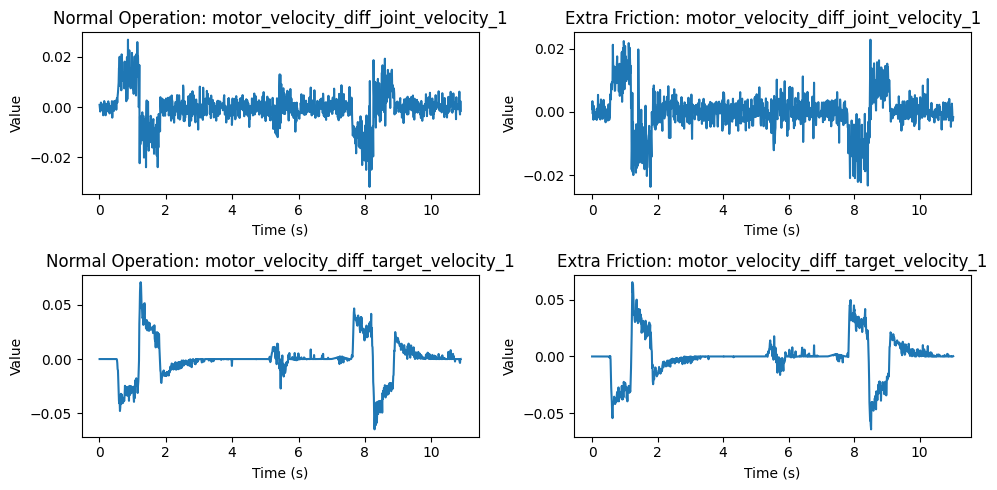

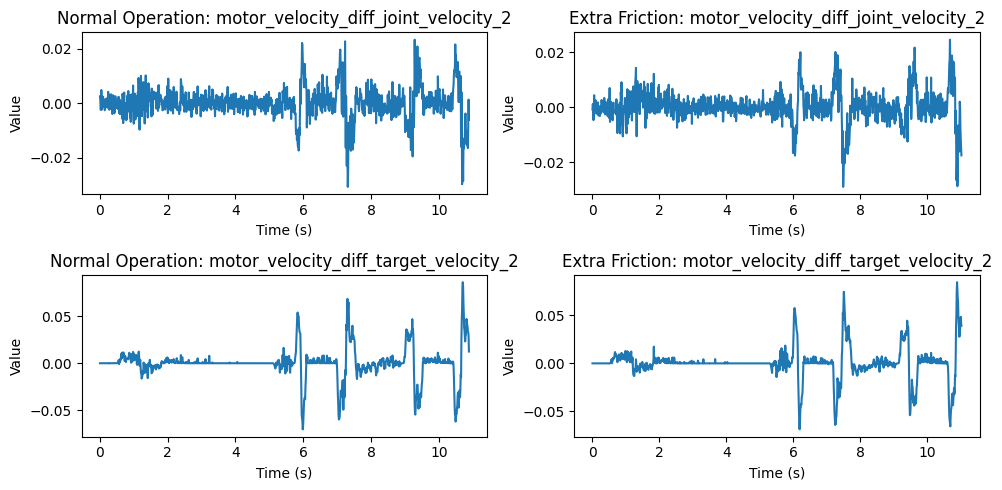

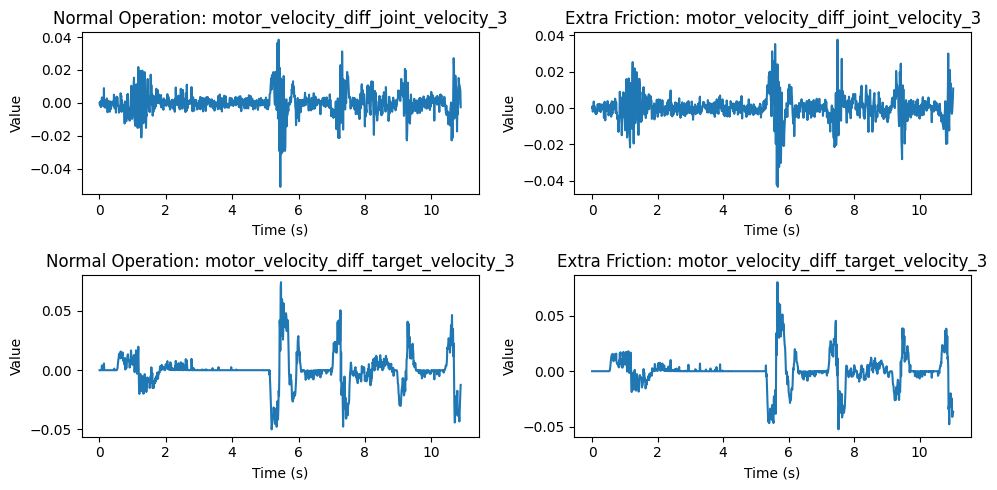

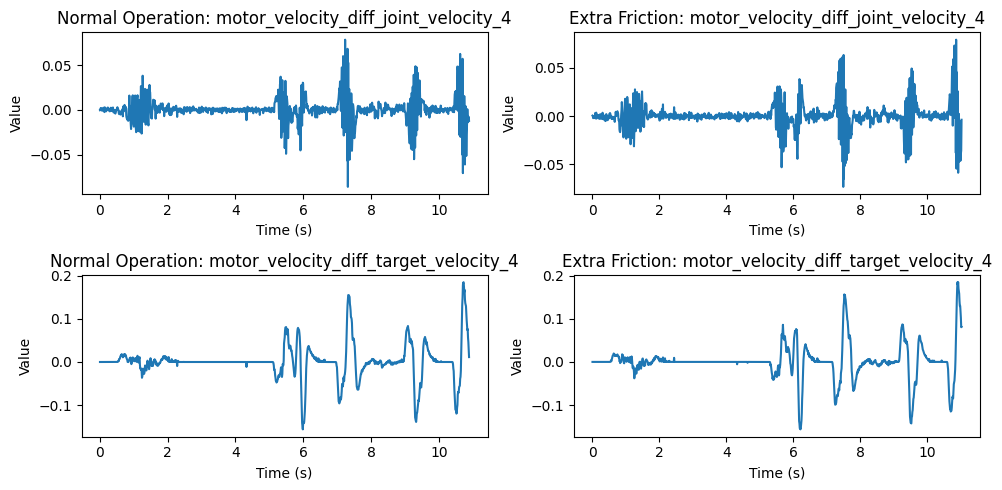

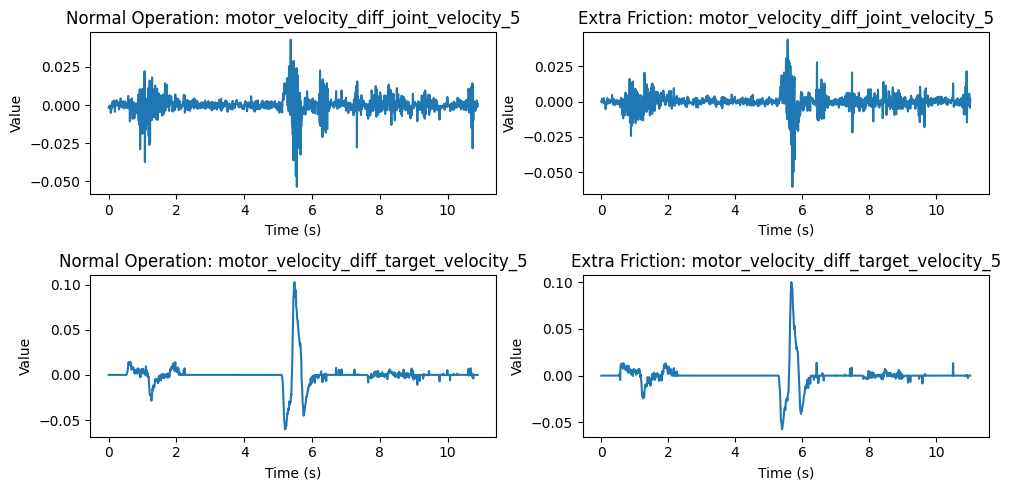

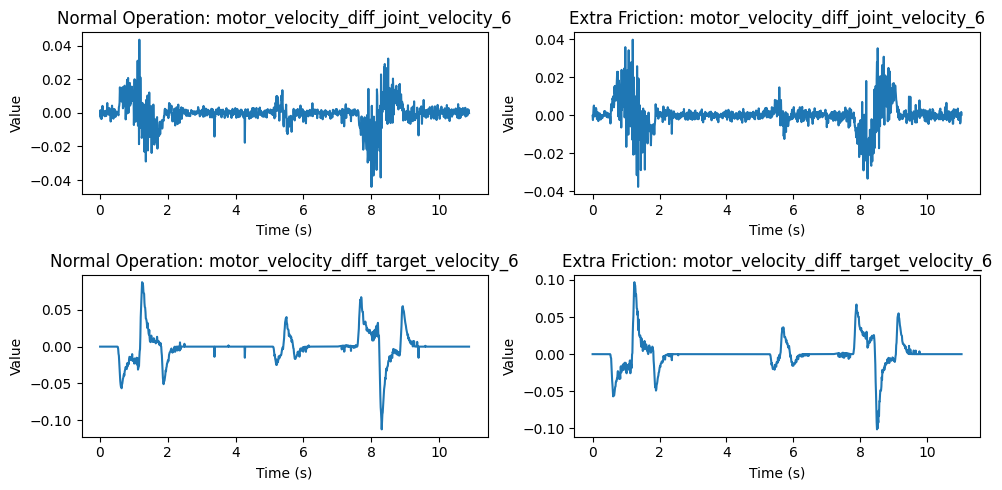

In [6]:
def plot_feature_comparison(clean_sample, anomaly_sample, motor_num, features_to_plot):
    """
    Plots a comparison of selected features between clean and anomalous samples.

    Args:
        clean_sample (pd.DataFrame): A time series of a normal operation
        anomaly_sample (pd.DataFrame): A time series of an anomalous operation
        motor_num (int): Motor number to examine
        features_to_plot (list): List of feature patterns to plot (motor number will be appended)

    Returns:
        plt.Figure: The matplotlib figure containing the plots
    """
    # Format feature names with motor number
    variables = [f"{feature}_{motor_num}" for feature in features_to_plot]
    num_vars = len(variables)

    # Create plot grid
    fig, axes = plt.subplots(num_vars, 2, figsize=(10, 2.5 * num_vars))

    # Create comparison plots
    for i, variable in enumerate(variables):
        # Clean sample plot
        axes[i, 0].plot(clean_sample["time"], clean_sample[variable])
        axes[i, 0].set_title(f"Normal Operation: {variable}")
        axes[i, 0].set_xlabel("Time (s)")
        axes[i, 0].set_ylabel("Value")

        # Anomaly sample plot
        axes[i, 1].plot(anomaly_sample["time"], anomaly_sample[variable])
        axes[i, 1].set_title(f"Extra Friction: {variable}")
        axes[i, 1].set_xlabel("Time (s)")
        axes[i, 1].set_ylabel("Value")

    plt.tight_layout()
    return fig

print("Generating feature comparison plots...")
for motor_num in range(1, 7):
    feature_patterns = [
        "motor_velocity_diff_joint_velocity",
        "motor_velocity_diff_target_velocity"
    ]
    plot_feature_comparison(
        clean_sample,
        extra_friction_sample,
        motor_num,
        feature_patterns
    )
    # plt.show()

## Data Preparation for Model Training

Prepare our data to fit the input shape of the neural network, and likewise reoganize it with definitive classnames.

In [7]:
print("Preparing data for model training...")

metadata_columns = ["category", "anomaly", "sample", "time"]
numeric_cols = [col for col in our_data.columns if col not in metadata_columns]

print("Standardizing numeric features...")
scaler = StandardScaler()
our_data[numeric_cols] = scaler.fit_transform(our_data[numeric_cols])
print("Standardization complete.")

MODEL_CONFIG = {
    "HIDDEN_LAYERS": 2,
    "NODES_PER_LAYER": 64
}

X = []
y = []

# Class index to name mapping
CLASS_LABELS = {
    0: "Normal",
    1: "Additional friction",
    2: "Add. axis weight",
    3: "Varying can weight",
    4: "Miscommutation",
    5: "Unstable platform"
}
# Mapping anomaly category index to label index in y
ANOMALY_CATEGORY_TO_LABEL = {
    0: 1,   # Additional friction
    1: 2,   # Add. axis weight
    7: 3,   # Varying can weight
    10: 4,  # Miscommutation
    11: 5   # Unstable platform
}

print("Preparing normal samples...")
for sample in clean_samples:
    X.append(sample.drop(columns=metadata_columns))
    y.append(np.zeros(len(sample), dtype=int))

for anomaly_cat, label in ANOMALY_CATEGORY_TO_LABEL.items():
    print(f"Preparing anomaly samples (category {anomaly_cat}: {CLASS_LABELS[label]})...")
    for sample in anomaly_samples[anomaly_cat]:
        X.append(sample.drop(columns=metadata_columns))
        y.append(np.full(len(sample), label, dtype=int))

X = pd.concat(X, ignore_index=True)
y = np.concatenate(y)

class_counts = [np.sum(y == i) for i in range(len(CLASS_LABELS))]
print(f"Dataset prepared: {X.shape[0]} samples with {X.shape[1]} features")
for i, name in CLASS_LABELS.items():
    print(f"{name}: {class_counts[i]} samples")

Preparing data for model training...
Standardizing numeric features...
Standardization complete.
Preparing normal samples...
Preparing anomaly samples (category 0: Additional friction)...
Preparing anomaly samples (category 1: Add. axis weight)...
Preparing anomaly samples (category 7: Varying can weight)...
Preparing anomaly samples (category 10: Miscommutation)...
Preparing anomaly samples (category 11: Unstable platform)...
Dataset prepared: 2047685 samples with 87 features
Normal: 1488328 samples
Additional friction: 159269 samples
Add. axis weight: 172488 samples
Varying can weight: 88147 samples
Miscommutation: 98580 samples
Unstable platform: 40873 samples


In [8]:
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Splitting data into training and testing sets...
Training set: 1638148 samples, Test set: 409537 samples


## Model Training and Evaluation

This function handles the creation and training of the neural network.

In [9]:
def train_anomaly_detection_model(X, y, model_params=None, save_path=None):
    """
    Train a multiclass anomaly detection model using a neural network.

    Args:
        X (pd.DataFrame): Feature dataset
        y (np.ndarray): Target labels (0: clean, 1: anomaly0, 2: anomaly1)
        model_params (dict, optional): Neural network hyperparameters
        save_path (str, optional): Path to save the trained model

    Returns:
        tuple: (trained_model, evaluation_metrics)
    """
    # Set default parameters if none provided
    if model_params is None:
        model_params = {
            'hidden_layer_sizes': (100, 50),
            'activation': 'relu',
            'solver': 'adam',
            'learning_rate_init': 0.001,
            'max_iter': 200,
            'random_state': 42,
            'verbose': True
        }

    # 2. Create and train the neural network (multiclass)
    print("\nTraining neural network model...")
    print(f"Model architecture: {model_params['hidden_layer_sizes']} hidden layers")

    # Compute class weights to handle imbalance
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    # class_weight_dict = {i: w for i, w in zip(classes, class_weights)}

    mlp = MLPClassifier(**model_params) #, class_weight=class_weight_dict)
    mlp.fit(X_train, y_train)

    # 4. Save the model if a path is specified
    if save_path:
        joblib.dump(mlp, save_path)
        print(f"Model saved to {save_path}")

    return mlp

## Confusion Matrix Visualization

Visualize the model's qualities by displaying a confusion matrix.

In [10]:
def plot_confusion_matrix(confusion_matrix_data, class_names=None):
    """
    Plot and format a confusion matrix visualization.

    Args:
        confusion_matrix_data (numpy.ndarray): The confusion matrix
        class_names (list): Names of the classes
    """
    if class_names is None:
        class_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_data,
                                  display_labels=class_names)

    disp.plot(cmap='Blues', values_format='d', ax=ax)

    # Add title and labels
    plt.title('Confusion Matrix', fontsize=15)
    plt.grid(False)

    # Add text with overall accuracy
    total = np.sum(confusion_matrix_data)
    correct = np.trace(confusion_matrix_data)
    accuracy = correct / total

    plt.figtext(0.5, 0.01, f'Overall Accuracy: {accuracy:.4f}',
                ha='center', fontsize=12)

    plt.tight_layout()
    return fig

## Learning Curve Visualization

Explore how the model behaved over time while learning.

In [11]:
def plot_model_learning_curve(model, X, y, cv=5):
    """
    Plot learning curves for the trained model to diagnose overfitting/underfitting.

    Args:
        model: Trained model
        X: Features
        y: Target labels
        cv: Number of cross-validation folds
    """
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.grid()
    ax.fill_between(train_sizes, train_mean - train_std,
                    train_mean + train_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_mean - test_std,
                    test_mean + test_std, alpha=0.1, color="g")
    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    ax.set_title("Learning Curve", fontsize=14)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Accuracy")
    ax.legend(loc="best")

    return fig

## Main Execution: Train and Evaluate Model

Assemble all configurations and execute the training portion of the code.

In [12]:
model_config = {
    'hidden_layer_sizes': (100, 50),
    'activation': 'relu',
    'solver': 'adam',
    'learning_rate_init': 0.001,
    'max_iter': 12,
    'random_state': 47,
    'verbose': True,
    'early_stopping': True,
    'validation_fraction': 0.1
}

model_save_path = "robot_anomaly_detection_model.pkl"
model = train_anomaly_detection_model(
    X, y,
    model_params=model_config,
    save_path=model_save_path
) # Stores our model


Training neural network model...
Model architecture: (100, 50) hidden layers
Iteration 1, loss = 0.80027168
Validation score: 0.776168
Iteration 2, loss = 0.67022984
Validation score: 0.793017
Iteration 3, loss = 0.63061337
Validation score: 0.798108
Iteration 4, loss = 0.60602467
Validation score: 0.802985
Iteration 5, loss = 0.59040251
Validation score: 0.811556
Iteration 6, loss = 0.57943076
Validation score: 0.813906
Iteration 7, loss = 0.57060752
Validation score: 0.816629
Iteration 8, loss = 0.56366189
Validation score: 0.812886
Iteration 9, loss = 0.55904039
Validation score: 0.821555
Iteration 10, loss = 0.55437627
Validation score: 0.822135
Iteration 11, loss = 0.54961279
Validation score: 0.820468
Iteration 12, loss = 0.54570858
Validation score: 0.821787
Model saved to robot_anomaly_detection_model.pkl


C:\Users\orpin\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (12) reached and the optimization hasn't converged yet.
  warnings.warn(


## Use the existing model to make predictions and adjust thresholds accordingly.

After the model has been created, and is readily available to make predictions,
we may use it to evaluate its performence.


Evaluating model performance...

----- Model Evaluation Results -----
Accuracy: 0.8231

Detailed Classification Report:
                     precision    recall  f1-score   support

             Normal       0.83      0.97      0.90    297666
Additional friction       0.77      0.48      0.59     31854
   Add. axis weight       0.83      0.52      0.64     34498
 Varying can weight       0.64      0.07      0.13     17629
     Miscommutation       0.75      0.57      0.65     19716
  Unstable platform       0.69      0.18      0.28      8174

           accuracy                           0.82    409537
          macro avg       0.75      0.47      0.53    409537
       weighted avg       0.81      0.82      0.79    409537


Confusion Matrix:
[[290033   2548   2145    424   2261    255]
 [ 16136  15269    200    126     34     89]
 [ 14994    303  17792      1   1392     16]
 [ 14777   1203    113   1249     13    274]
 [  7293     36   1110      3  11265      9]
 [  5861    509    131

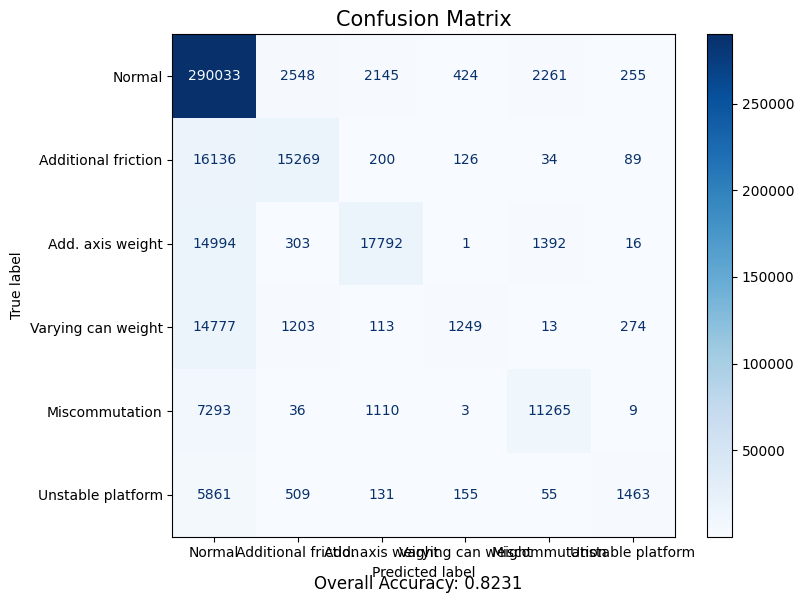

In [21]:
print("\nEvaluating model performance...")

predictions_powers = [
    1, # x_0: Overly recognized
    1, # x_3:
    1, # x_2
    1, # x_3: Hardly recognized
    1, # x_4
    1 # x_5: Hardly recognized
]

# Get probability distributions
y_proba = model.predict_proba(X_test)

# Apply probability powers to each class probability
y_modified_proba = np.array([
    [pow(prob, predictions_powers[i]) for i, prob in enumerate(sample_proba)]
    for sample_proba in y_proba
])

# Normalize probabilities to sum to 1 after modification
y_modified_proba = y_modified_proba / y_modified_proba.sum(axis=1, keepdims=True)

# Get predictions from modified probabilities
y_pred = np.argmax(y_modified_proba, axis=1)

# Calculate various metrics
target_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=target_names)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASS_LABELS))))

# Collect metrics
metrics = {
    'accuracy': accuracy,
    'classification_report': report,
    'confusion_matrix': cm,
    'y_test': y_test,
    'y_pred': y_pred
}

# Output evaluations
print("\n----- Model Evaluation Results -----")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print("\nDetailed Classification Report:")
print(metrics['classification_report'])

print("\nConfusion Matrix:")
print(metrics['confusion_matrix'])

cm_fig = plot_confusion_matrix(metrics['confusion_matrix'], class_names=[CLASS_LABELS[i] for i in range(len(CLASS_LABELS))])
plt.figure(cm_fig.number)
plt.savefig('confusion_matrix.png')

'''
lc_fig = plot_model_learning_curve(model, X, y)
lc_fig = plot_model_learning_curve(model, X, y)
plt.figure(lc_fig.number)
plt.savefig('learning_curve.png')
print("\nVisualizations saved as 'confusion_matrix.png' and 'learning_curve.png'")
'''

loaded_model = joblib.load(model_save_path)
loaded_accuracy = accuracy_score(metrics['y_test'], loaded_model.predict(X_test))
print(f"\nVerification - Loaded model accuracy: {loaded_accuracy:.4f}")

plt.show()